<img src="../imagens/assets/Cabecalho.png">

# Simulando Vida com Partículas
`Autor:` Filipi Martins

---

# Índice
1. [Introdução](#interacoes)
2. [Base do jogo](#base_do_jogo)
3. [Partículas](#particulas)
    1. [Criando as partículas](#criando-as-particulas)
    2. [Gerando partículas aleatoriamente](#particulas-aleatorias)
4. [Interações](#interacoes)
    1. [Força linear](#forca-linear)
    2. [Força com repulsão](#forca-com-repulsao)
    3. [Simulando 2 esécies](#2-especies)
    4. [Simulando 3 espécies](#3-especies)
    5. [Melhorando a performance](#performance)
5. [XKCD Relevante](#xkcd-relevante)
5. [Referências](#referencias)

<a id="introducao"></a>
## 1. Introdução
> "Sometimes it's hard for me to believe that all of the complexity that we see in our life can arise from particle physics. Even humans thoughts, and emotions. But for me, seeing how Particle Life can already create these lifelike structures in a much simpler universe makes all of it a bit more believable."<br/>
> -<cite> Tom Mohr, criador do Particle Life [[1](#referencias)]</cite>

De onde vem a aparente complexidade do nosso mundo? Como regras simples de atração e repulsão entre partículas pode gerar algo tão estruturado quanto um organismo vivo? Essas e outras perguntas podem ser respondidas a partir do conceito de `emergência`: quando uma grande quantia de entidades distintas atuam em um mesmo ambiente a partir de um conjunto de regras relativamente simples, a multiplicidade das interações pode gerar, no coletivo, comportamentos complexos [[2](#referencias)].

Imagine uma partícula vermelha. Agora imagine que partículas vermelhas adoram partículas azuis. Mas as partículas azuis fogem das partículas vermelhas. Mas também existem partículas verdes, pelas quais as azuis se atraem. Contudo as vermelhas acabaram de perceber uma outra partícula amarela pela qual elas também são atraídas.

Quando temos poucas partículas, pode parecer fácil prever o comportamento geral do sistema. Entretanto, cada nova partícula ou espécie adicionada modifica o comportamento coletivo. Todas essas possíveis interações resultam em um sistema complexo, difícil de prever e que pode mudar completamente com pequenas alterações nas regras iniciais.

O objetivo deste projeto é simular o surgimento desse comportamento complexo a partir de interações simples de atração e repulsão entre partículas. Para isso, foi utilizada a biblioteca `pygame-ce` para renderizar os gráficos, e `numpy` para operações vetoriais.

<b>Atenção:</b> a simulação apresentada a seguir não tem o intuito de ser uma simulação física. As forças entre as partículas são assimétricas, o que vai contra a 3ª Lei de Newton. Não necessariamente a força de atração que uma partícula sente pela outra é igualmente retribuida. Nesse sentido, podemos pensar cada partícula como possuidora de um reservatório de energia interno, que as possibilita de perseguir ou se afastar das suas companheiras. Dessa forma, talvez seja adequado pensar em um analogia mais biológica do que física, ou então uma mescla entre as duas.

<a id="base_do_jogo"></a>
## 2. Base do jogo

Vamos começar definindo a base do nosso jogo, utilizando a biblioteca *Pygame*.

Nesse caso, estou utilizando a versão `pygame-ce 2.5.7 (SDL 2.32.10, Python 3.13.7)`.

Primeiramente, importamos a biblioteca com a célula a seguir:

In [34]:
# Importando bibliotecas
import pygame

Então, podemos definir uma classe `Game` que será responsável por organizar toda a lógica da nossa simulação. (código base ajustado de [[3](#referencias)])

Ela terá os seguintes atributos:
- running (bool): Indica se o jogo está rodando
- display (pygame.Surface): A superfície de exibição do jogo
- clock (pygame.time.Clock): Relógio para controlar o FPS
- width (int): Largura da janela do jogo
- height (int): Altura da janela do jogo
- size (tuple): Tamanho da janela do jogo (width, height)
- max_fps (int): Taxa máxima de quadros por segundo
    
E os seguintes métodos:
- \_\_init\_\_(self, width=700, height=700, max_fps=60): Inicializa os atributos do jogo
- on_init(self): Configura o ambiente do jogo
- on_event(self, event): Lida com os eventos do jogo
- on_loop(self): Atualiza a lógica do jogo
- on_render(self): Renderiza os elementos do jogo na tela
- on_cleanup(self): Limpa os recursos do jogo
- on_execute(self): Executa o loop principal do jogo 

In [ ]:
# Código base ajustado de [3]

class Game:
    """Classe base para o jogo
    
    Atributos:
        running (bool): Indica se o jogo está rodando
        display (pygame.Surface): A superfície de exibição do jogo
        clock (pygame.time.Clock): Relógio para controlar o FPS
        width (int): Largura da janela do jogo
        height (int): Altura da janela do jogo
        size (tuple): Tamanho da janela do jogo (width, height)
        max_fps (int): Taxa máxima de quadros por segundo
    
    Métodos:
        __init__(self, width=700, height=700, max_fps=60): Inicializa os atributos do jogo
        on_init(self): Configura o ambiente do jogo
        on_event(self, event): Lida com os eventos do jogo
        on_loop(self): Atualiza a lógica do jogo
        on_render(self): Renderiza os elementos do jogo na tela
        on_cleanup(self): Limpa os recursos do jogo
        on_execute(self): Executa o loop principal do jogo
    """
    def __init__(self, width = 700, height = 700, max_fps = 60):
        """Inicializa os atributos do jogo.

        Inicializa os atributos do jogo, incluindo a largura e altura da janela, a taxa máxima de quadros por segundo, e as variáveis para controlar o estado do jogo e a exibição.

        Args:
            width (int, optional): Largura da janela do jogo. Padrão é 700.
            height (int, optional): Altura da janela do jogo. Padrão é 700.
            max_fps (int, optional): Taxa máxima de quadros por segundo. Padrão é 60.
        """
        self.running = True
        self.display = None
        self.clock = None
        self.width = width
        self.height = height
        self.size = (self.width, self.height)
        self.max_fps = max_fps
    
    def on_init(self):
        """Configura o ambiente do jogo.

        Configura o ambiente do jogo, inicializando o Pygame, criando a janela de exibição e configurando o relógio para controlar o FPS.

        Returns:
            bool: Retorna True se a inicialização for bem-sucedida, caso contrário, retorna False.
        """

        pygame.init()
        self.display = pygame.display.set_mode(self.size)
        self.clock = pygame.time.Clock()
        return True
    
    def on_event(self, event):
        """Lida com os eventos do jogo.
        
        Lida com os eventos do jogo, verificando se o evento é do tipo QUIT para encerrar o jogo.
        
        Args:
            event (pygame.event.Event): O evento a ser processado.
        """
        if event.type == pygame.QUIT:
            self.running = False
    
    def on_loop(self):
        """Atualiza a lógica do jogo.
        
        Atualiza os elementos do jogo, como a posição dos objetos, e cálculos de interações. Este método é chamado a cada iteração do loop principal do jogo.
        """
        pass

    def on_render(self):
        """Renderiza os elementos do jogo na tela.
        
        Renderiza os elementos do jogo na tela, desenhando os objetos e atualizando a exibição. Este método é chamado a cada iteração do loop principal do jogo.
        """
        pass

    def on_cleanup(self):
        """Limpa os recursos do jogo.
        
        Limpa os recursos do jogo, encerrando o Pygame e liberando quaisquer recursos alocados. Este método é chamado quando o jogo é encerrado.
        """
        pygame.quit()

    def on_execute(self):
        """Executa o loop principal do jogo.
        
        Executa o loop principal do jogo, chamando os métodos de inicialização, eventos, lógica e renderização em cada iteração. O loop continua até que a variável 'running' seja definida como False.
        """
        self.running = self.on_init()

        while self.running:

            for event in pygame.event.get():
                self.on_event(event)

            self.on_loop()
            self.on_render()

            self.clock.tick(self.max_fps)

        self.on_cleanup()

Agora, para rodar o jogo base, podemos instanciar um objeto da classe Game e chamar a função `on_execute()`.

Por enquanto, ainda não adicionamos nada na nossa simulação, então teremos apenas uma tela preta.

__Atenção:__ Ao rodar células com `game.on_execute()`, confire se uma janela do pygame abriu no plano de fundo. A célula só finaliza seu processamento ao fechar a janela do jogo.

In [38]:
game = Game()
game.on_execute()

<a id="particulas"></a>
## 3. Partículas

<a id="criando-as-particulas"></a>
### 3.1 Criando as partículas

Vamos começar definindo nossas partículas. Cada partícula terá três características principais:
- espécie
- posição
- velocidade

In [ ]:
class Particle:
    """Classe para representar uma partícula no jogo
    
    Atributos:
        species (Species): A espécie da partícula
        position (list): A posição da partícula na tela [x, y]
        velocity (list): A velocidade da partícula [vx, vy]
    
    Métodos:
        __init__(self, species, position=[0, 0], velocity=[0, 0]): Inicializa os atributos da partícula
        on_render(self, surface): Renderiza a partícula na superfície fornecida
    """

    def __init__(self, species, position = None, velocity = None):
        """Inicializa os atributos da partícula.
        
        Inicializa os atributos da partícula, incluindo a espécie, posição e velocidade.
        
        Args:
            species (Species): A espécie da partícula
            position (list, optional): A posição inicial da partícula na tela [x, y]. Padrão é [0, 0].
            velocity (list, optional): A velocidade inicial da partícula [vx, vy]. Padrão é [0, 0].
        """
        self.species = species
        
        self.position = position
        if self.position == None:
            self.position = [0, 0]

        self.velocity = velocity
        if self.velocity == None:
            self.velocity = [0, 0]
    
    def on_render(self, surface): 
        """Renderiza a partícula na superfície fornecida.
        
        Renderiza a partícula na superfície fornecida, desenhando um círculo com a cor e tamanho definidos pela espécie da partícula.
        
        Args:
            surface (pygame.Surface): A superfície onde a partícula deve ser renderizada.
        """
        pygame.draw.circle(surface, self.species.color, self.position, self.species.size)
    

A espécie da partícula é responsável por definir sua cor, seu tamanho e as interações com os demais tipos. Por enquanto, vamos deixar as interações de lado.

In [39]:
class Species:
    """Classe para representar uma espécie de partícula no jogo
    
    Atributos:
        id (int): Identificador único da espécie
        color (tuple): Cor da espécie (R, G, B)
        size (int): Tamanho da partícula da espécie
        
    Métodos:
         __init__(self, id, color, size=1): Inicializa os atributos da espécie
    """

    def __init__(self, id, color, size = 1):
        """Inicializa os atributos da espécie.
        
        Inicializa os atributos da espécie, incluindo o identificador único, a cor e o tamanho das partículas da espécie.
        
        Args:
            id (int): Identificador único da espécie
            color (tuple): Cor da espécie (R, G, B)
            size (int, optional): Tamanho da partícula da espécie. Padrão é 1.
        """
        self.id = id
        self.color = color
        self.size = size

Vamos atualizar a classe de jogo para conseguir receber as partículas. Para isso, vamos adicionar um atributo `particles` que irá armazenar as partículas do jogo; um método `on_add_particle()` para adicionar as partículas à lista; e modificar o método `on_render()` para renderizar todas as partículas.

In [ ]:
class Game:
    """Classe base para o jogo
    
    Atributos:
        running (bool): Indica se o jogo está rodando
        display (pygame.Surface): A superfície de exibição do jogo
        clock (pygame.time.Clock): Relógio para controlar o FPS
        width (int): Largura da janela do jogo
        height (int): Altura da janela do jogo
        size (tuple): Tamanho da janela do jogo (width, height)
        max_fps (int): Taxa máxima de quadros por segundo
        particles (list): Lista de partículas no jogo
    
    Métodos:
        __init__(self, width=700, height=700, max_fps=60): Inicializa os atributos do jogo
        on_init(self): Configura o ambiente do jogo
        on_add_particle(self, particle): Adiciona uma partícula à lista de partículas do jogo
        on_event(self, event): Lida com os eventos do jogo
        on_loop(self): Atualiza a lógica do jogo
        on_render(self): Renderiza os elementos do jogo na tela
        on_cleanup(self): Limpa os recursos do jogo
        on_execute(self): Executa o loop principal do jogo
    """
    def __init__(self, width = 700, height = 700, max_fps = 60):
        """Inicializa os atributos do jogo.

        Inicializa os atributos do jogo, incluindo a largura e altura da janela, a taxa máxima de quadros por segundo, e as variáveis para controlar o estado do jogo e a exibição.

        Args:
            width (int, optional): Largura da janela do jogo. Padrão é 700.
            height (int, optional): Altura da janela do jogo. Padrão é 700.
            max_fps (int, optional): Taxa máxima de quadros por segundo. Padrão é 60.
        """
        self.running = True
        self.display = None
        self.clock = None
        self.width = width
        self.height = height
        self.size = (self.width, self.height)
        self.max_fps = max_fps

        # Lista de partículas
        self.particles = []
    
    def on_init(self):
        """Configura o ambiente do jogo.

        Configura o ambiente do jogo, inicializando o Pygame, criando a janela de exibição e configurando o relógio para controlar o FPS.

        Returns:
            bool: Retorna True se a inicialização for bem-sucedida, caso contrário, retorna False.
        """
        pygame.init()
        self.display = pygame.display.set_mode(self.size)
        self.clock = pygame.time.Clock()
        return True

    def on_add_particle(self, particle):
        """Adiciona uma partícula à lista de partículas do jogo.

        Adiciona uma partícula à lista de partículas do jogo, permitindo que ela seja renderizada e atualizada durante o loop principal do jogo.

        Args:
            particle (Particle): A partícula a ser adicionada.
        """
        self.particles.append(particle)
    
    def on_event(self, event):        
        """Lida com os eventos do jogo.
        
        Lida com os eventos do jogo, verificando se o evento é do tipo QUIT para encerrar o jogo.
        
        Args:
            event (pygame.event.Event): O evento a ser processado.
        """
        if event.type == pygame.QUIT:
            self.running = False
    
    def on_loop(self):
        """Atualiza a lógica do jogo.
        
        Atualiza os elementos do jogo, como a posição dos objetos, e cálculos de interações. Este método é chamado a cada iteração do loop principal do jogo.
        """
        pass

    def on_render(self):
        """Renderiza os elementos do jogo na tela.
        
        Renderiza os elementos do jogo na tela, desenhando os objetos e atualizando a exibição. Este método é chamado a cada iteração do loop principal do jogo.
        """
        # Limpa a tela
        self.display.fill((20, 20, 20))

        # Renderiza as partículas
        for particle in self.particles:
            particle.on_render(self.display)

        pygame.display.flip()

    def on_cleanup(self):
        """Limpa os recursos do jogo.
        
        Limpa os recursos do jogo, encerrando o Pygame e liberando quaisquer recursos alocados. Este método é chamado quando o jogo é encerrado.
        """
        pygame.quit()

    def on_execute(self):
        """Executa o loop principal do jogo.
        
        Executa o loop principal do jogo, chamando os métodos de inicialização, eventos, lógica e renderização em cada iteração. O loop continua até que a variável 'running' seja definida como False.
        """
        self.running = self.on_init()

        while self.running:

            for event in pygame.event.get():
                self.on_event(event)

            self.on_loop()
            self.on_render()

            self.clock.tick(self.max_fps)

        self.on_cleanup()

Agora basta criarmos algumas partículas e iniciar o jogo. Por enquanto, temos apenas uma tela preta com 4 partículas.

In [47]:
game = Game()

red_species = Species(0, (255,0,0), 4)

game.on_add_particle(Particle(red_species, [100, 200]))
game.on_add_particle(Particle(red_species, [200, 600]))
game.on_add_particle(Particle(red_species, [450, 30]))
game.on_add_particle(Particle(red_species, [320, 460]))

game.on_execute()

<a id="particulas-aleatorias"></a>
### 3.2 Gerando partículas aleatoriamente

Mas adicionar cada partícula manualmente não é viável, por isso criaremos uma função responsável por adicionar n partículas aleatórias na tela.

Para isso, vamos importar a biblioteca `random` de aleatoriedade.

In [48]:
# Importando a biblioteca de aleatoriedade
import random

In [49]:
def instantiate_particles(number_of_particles, species, game):
    """Instancia um número específico de partículas no jogo.
    
    Instancia um número específico de partículas no jogo, escolhendo aleatoriamente a espécie e a posição de cada partícula dentro dos limites da janela do jogo.
    
    Args:
        number_of_particles (int): O número de partículas a ser instanciado.
        species (list): A lista de espécies disponíveis para as partículas.
        game (Game): A instância do jogo onde as partículas serão adicionadas.
    """
    for i in range(number_of_particles):
        particle_species = random.choice(species)
        particle_x = random.randint(0, game.width)
        particle_y = random.randint(0, game.height)
        
        new_particle = Particle(particle_species, [particle_x, particle_y])
        game.on_add_particle(new_particle)

Agora podemos rodar a simulação novamente, criando 500 partículas aleatórias

In [51]:
species = [red_species]

instantiate_particles(500, species, game)

game.on_execute()

<a id="interacoes"></a>
## 4. Interações

<a id="forca-linear"></a>
### 4.1 Força linear

Agora que já temos as partículas, precisamos fazer elas interagirem entre si.

Para isso, criaremos uma função de força baseada na distância normalizada entre duas partículas. Por enquanto, vamos fazer que essa força atue linearmente até uma certa distância, que chamaremos de visão, atraindo partículas próximas umas das outras.

Primeiro, vamos importar as bibliotecas necessárias.

In [52]:
# Importando bibliotecas de operações matemáticas e de construção de gráficos
import math
import numpy as np
from matplotlib import pyplot as plt

Essa será nossa função de força que define a atração das partículas. Por enquanto, vamos fazê-la crescer linearmente.

In [57]:
def force_function(dist, attraction):
    """Calcula a força de atração ou repulsão das partículas.
    
    Calcula a força de atração ou repulsão entre partículas com base na distância entre elas e na força de atração definida.

    Args:
        dist (float): A distância entre as partículas.
        attraction (float): A força de atração ou repulsão entre as partículas.

    Returns:
        float: A força calculada com base na distância e na atração.
    """
    if 0 <= dist <= 1:
        return dist * attraction

    return 0

Vamos fazer também uma função suporte para visualizar a função de força.

In [58]:
# Função suporte para plotagem de gráficos
def plot_function(function, start, end, resolution, *args):
    """Plota uma função matemática em um intervalo específico.
    
    Plota uma função matemática em um intervalo específico, gerando um gráfico da função com base nos valores calculados para cada ponto no intervalo.
    
     Args:
        function (callable): A função matemática a ser plotada.
        start (float): O início do intervalo para plotagem.
        end (float): O fim do intervalo para plotagem.
        resolution (int): O número de pontos a serem calculados no intervalo.
        *args: Argumentos adicionais a serem passados para a função matemática.
    """
    x = np.linspace(start, end, resolution)
    y = [function(xi, *args) for xi in x]

    plt.plot(x, y)
    plt.title(function.__name__)
    plt.show()

Visualizando a função criada anteriormente, temos:

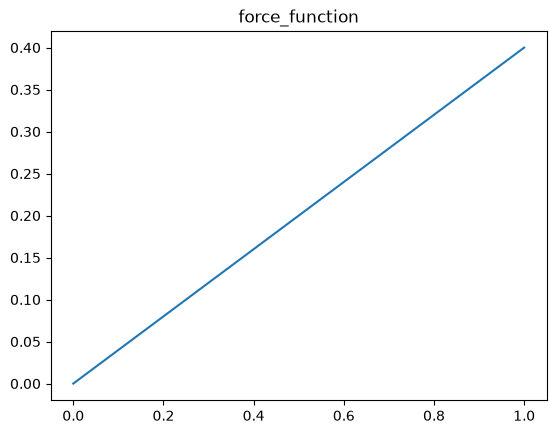

In [59]:
plot_function(force_function, 0, 1, 1000, 0.4)

Vamos criar também uma matriz de interações, responsável por ditar a interaçao de cada spécie uma com a outra.
Cada interação é composta por uma tupla que guarda 2 valores: atração e visão.

Quando o valor de atração é positivo, a partícula se sente atraída pela outra, caso contrário, ela é repelida.

Como só temos uma espécie, vamos ter apenas um tipo de interação (dela com ela mesma). Nesse caso, definimos uma interação atrativa em um raio de 100 pixeis.

In [60]:
interactions = [
    [(0.2, 100)]
]

Também definiremos uma constante de atrito, para restringir o movimento das nossas partículas

In [61]:
friction = 0.3

Com a função de força definia, podemos implementá-la nas nossas partículas.

In [ ]:
class Particle:
    """Classe para representar uma partícula no jogo
    
    Atributos:
        species (Species): A espécie da partícula
        position (list): A posição da partícula na tela [x, y]
        new_position (list): A nova posição da partícula na tela [x, y] (usada para calcular a próxima posição com base na velocidade)
        velocity (list): A velocidade da partícula [vx, vy]
    
    Métodos:
        __init__(self, species, position=[0, 0], velocity=[0, 0]): Inicializa os atributos da partícula
        on_render(self, surface): Renderiza a partícula na superfície fornecida
    """

    def __init__(self, species, position = None, velocity = None):
        """Inicializa os atributos da partícula.
        
        Inicializa os atributos da partícula, incluindo a espécie, posição e velocidade.
        
        Args:
            species (Species): A espécie da partícula
            position (list, optional): A posição inicial da partícula na tela [x, y]. Padrão é [0, 0].
            velocity (list, optional): A velocidade inicial da partícula [vx, vy]. Padrão é [0, 0].
        """
        self.species = species

        self.position = position
        if self.position == None:
            self.position = [0, 0]

        self.new_position = position.copy()

        self.velocity = velocity
        if self.velocity == None:
            self.velocity = [0, 0]
    
    def on_render(self, surface): 
        """Renderiza a partícula na superfície fornecida.
        
        Renderiza a partícula na superfície fornecida, desenhando um círculo com a cor e tamanho definidos pela espécie da partícula.
        
        Args:
            surface (pygame.Surface): A superfície onde a partícula deve ser renderizada.
        """
        pygame.draw.circle(surface, self.species.color, self.position, self.species.size)
    
    def on_loop(self, particles, force_function, interactions, friction):
        """Atualiza a posição e velocidade da partícula com base nas interações com outras partículas.
        
        Atualiza a posição e velocidade da partícula com base nas interações com outras partículas, calculando as forças de atração ou repulsão e aplicando a fricção.
        
        Args:
             particles (list): A lista de partículas a serem consideradas para as interações.
             force_function (callable): A função para calcular a força de atração ou repulsão entre as partículas.
             interactions (list): A matriz de interações entre as espécies de partículas, onde cada elemento é uma tupla (attraction, vision).
             friction (float): O coeficiente de fricção a ser aplicado à velocidade da partícula.
        """
        force_x = 0
        force_y = 0

        for other_particle in particles:
            if other_particle.position == self.position:
                continue
        
            attraction, vision = interactions[self.species.id][other_particle.species.id]

            diff_x = other_particle.position[0] - self.position[0]
            diff_y = other_particle.position[1] - self.position[1]

            if abs(diff_x) >= vision or abs(diff_y) >= vision:
                continue

            distance = math.sqrt(diff_x ** 2 + diff_y ** 2)

            if distance > vision or distance <= 0:
                continue

            normal_distance = distance / vision

            force = force_function(normal_distance, attraction)

            force_x += force * (diff_x / distance)
            force_y += force * (diff_y / distance)
        
        self.velocity[0] += force_x
        self.velocity[1] += force_y

        self.new_position[0] += self.velocity[0]
        self.new_position[1] += self.velocity[1]

        self.velocity[0] *= 1 - friction
        if abs(self.velocity[0]) < 0.1:
            self.velocity[0] = 0
            
        self.velocity[1] *= 1 - friction
        if abs(self.velocity[1]) < 0.1:
            self.velocity[1] = 0

    def update_position(self):
        """Atualiza a posição da partícula para a nova posição calculada.
        
        Atualiza a posição da partícula para a nova posição calculada, permitindo que a partícula se mova com base na velocidade e nas interações com outras partículas.
        """
        self.position = self.new_position

Agora, implementamos no jogo a atualização das partículas no método `on_loop()`.

In [ ]:
class Game:
    """Classe base para o jogo
    
    Atributos:
        running (bool): Indica se o jogo está rodando
        display (pygame.Surface): A superfície de exibição do jogo
        clock (pygame.time.Clock): Relógio para controlar o FPS
        width (int): Largura da janela do jogo
        height (int): Altura da janela do jogo
        size (tuple): Tamanho da janela do jogo (width, height)
        max_fps (int): Taxa máxima de quadros por segundo
        particles (list): Lista de partículas no jogo
        interactions (list): Matriz de interações entre as espécies de partículas
        force_function (callable): Função para calcular a força de atração ou repulsão entre as partículas
        friction (float): Coeficiente de fricção a ser aplicado à velocidade da partícula
    
    Métodos:
        __init__(self, width=700, height=700, max_fps=60): Inicializa os atributos do jogo
        on_init(self): Configura o ambiente do jogo
        on_add_particle(self, particle): Adiciona uma partícula à lista de partículas do jogo
        on_event(self, event): Lida com os eventos do jogo
        on_loop(self): Atualiza a lógica do jogo
        on_render(self): Renderiza os elementos do jogo na tela
        on_cleanup(self): Limpa os recursos do jogo
        on_execute(self): Executa o loop principal do jogo
    """
    
    def __init__(self, interactions, force_function, friction, width = 700, height = 700, max_fps = 60):
        """Inicializa os atributos do jogo.

        Inicializa os atributos do jogo, incluindo as interações, a função de força, o coeficiente de fricção, a largura e altura da janela, a taxa máxima de quadros por segundo, e as variáveis para controlar o estado do jogo e a exibição.

        Args:
            interactions (list): A matriz de interações entre as espécies de partículas.
            force_function (callable): A função para calcular a força de atração ou repulsão entre as partículas.
            friction (float): O coeficiente de fricção a ser aplicado à velocidade da partícula.
            width (int, optional): Largura da janela do jogo. Padrão é 700.
            height (int, optional): Altura da janela do jogo. Padrão é 700.
            max_fps (int, optional): Taxa máxima de quadros por segundo. Padrão é 60.
        """
        self.running = True
        self.display = None
        self.clock = None
        self.width = width
        self.height = height
        self.size = (self.width, self.height)
        self.max_fps = max_fps
        self.particles = []

        self.interactions = interactions
        self.force_function = force_function
        self.friction = friction
    
    def on_init(self):
        """Configura o ambiente do jogo.

        Configura o ambiente do jogo, inicializando o Pygame, criando a janela de exibição e configurando o relógio para controlar o FPS.

        Returns:
            bool: Retorna True se a inicialização for bem-sucedida, caso contrário, retorna False.
        """
        pygame.init()
        self.display = pygame.display.set_mode(self.size)
        self.clock = pygame.time.Clock()
        return True

    def on_add_particle(self, particle):
        """Adiciona uma partícula à lista de partículas do jogo.

        Adiciona uma partícula à lista de partículas do jogo, permitindo que ela seja renderizada e atualizada durante o loop principal do jogo.

        Args:
            particle (Particle): A partícula a ser adicionada.
        """
        self.particles.append(particle)
    
    def on_event(self, event):
        """Lida com os eventos do jogo.
        
        Lida com os eventos do jogo, verificando se o evento é do tipo QUIT para encerrar o jogo.
        
        Args:
            event (pygame.event.Event): O evento a ser processado.
        """
        if event.type == pygame.QUIT:
            self.running = False
    
    def on_loop(self):
        """Atualiza a lógica do jogo.
        
        Atualiza os elementos do jogo, como a posição dos objetos, e cálculos de interações. Este método é chamado a cada iteração do loop principal do jogo.
        """

        # Atualiza as partículas
        for particle in self.particles:            
            particle.on_loop(self.particles, self.force_function, self.interactions, self.friction)
        
        for particle in self.particles:    
            particle.update_position()

    def on_render(self):
        """Renderiza os elementos do jogo na tela.
        
        Renderiza os elementos do jogo na tela, desenhando os objetos e atualizando a exibição. Este método é chamado a cada iteração do loop principal do jogo.
        """

        self.display.fill((20, 20, 20))

        for particle in self.particles:
            particle.on_render(self.display)

        pygame.display.flip()

    def on_cleanup(self):
        """Limpa os recursos do jogo.
        
        Limpa os recursos do jogo, encerrando o Pygame e liberando quaisquer recursos alocados. Este método é chamado quando o jogo é encerrado.
        """
        pygame.quit()

    def on_execute(self):
        """Executa o loop principal do jogo.
        
        Executa o loop principal do jogo, chamando os métodos de inicialização, eventos, lógica e renderização em cada iteração. O loop continua até que a variável 'running' seja definida como False.
        """
        self.running = self.on_init()

        while self.running:

            for event in pygame.event.get():
                self.on_event(event)

            self.on_loop()
            self.on_render()

            self.clock.tick(self.max_fps)

        self.on_cleanup()

Rodando o jogo, temos:

In [63]:
game = Game(interactions, force_function, friction)

red_species = Species(0, (255,0,0), 4)
species = [red_species]

instantiate_particles(300, species, game)

game.on_execute()

<a id="forca-com-repulsao"></a>
### 4.2 Força com repulsão

Como o esperado, as partículas apenas se atraem entre si, pois não apresentam nenhuma força de repulsão. Podemos alterar isso modificando a função de força para incluir uma repulsão em distâncias muito próximas, e uma força que seja proporcional à distância. (Função inspirada na implementaçã de Tom Mohr [[4]](#referencias))

In [64]:
def force_function(dist, attraction):
    """Calcula a força de atração ou repulsão das partículas.
    
    Calcula a força de atração ou repulsão entre partículas com base na distância entre elas e na força de atração definida.

    Args:
        dist (float): A distância entre as partículas.
        attraction (float): A força de atração ou repulsão entre as partículas.

    Returns:
        float: A força calculada com base na distância e na atração.
    """
    
    repulsion_intensity = -0.8
    repulsion_radius = 0.3

    if 0 <= dist < repulsion_radius:
        return dist * (-repulsion_intensity / repulsion_radius) + repulsion_intensity

    mid = repulsion_radius + ((1 - repulsion_radius) / 2)

    if repulsion_radius <= dist < mid:
        return (dist - repulsion_radius) * attraction / (mid - repulsion_radius)

    if mid <= dist <= 1:
        return -(1 - dist) * (-attraction / (1 - mid))

    return 0

Visualizando com nossa função suporte:

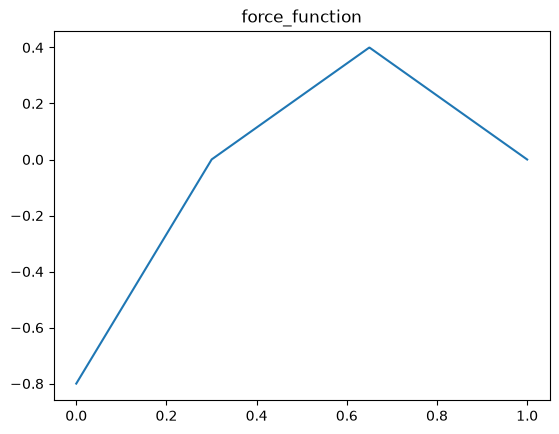

In [65]:
plot_function(force_function, -0, 1, 1000, 0.4)

Agora, se rodarmos a simulação com a nova `force_function` e a mesma atração de antes teremos:

In [66]:
interactions = [[(0.3, 100)]]

game = Game(interactions, force_function, friction)

red_species = Species(0, (255,0,0), 4)
species = [red_species]

instantiate_particles(300, species, game)

game.on_execute()

Se eu definir que as partículas terão apenas interações de repulsão, elas tentam se distribuir na tela

In [67]:
red_species = Species(0, (255,0,0), 4)
species = [red_species]

interactions = [
    [(-0.5, 100)]
]

game = Game(interactions, force_function, friction)

instantiate_particles(300, species, game)

game.on_execute()

<a id="2-especies"></a>
### 4.3 Simulando 2 espécies

Também podemos criar uma espécie azul, que se afasta da vermelha

In [86]:
red_species = Species(0, (255,0,0), 4)
blue_species = Species(1, (0, 0, 255), 4)
species = [red_species, blue_species]

interactions = [
    [(0.1, 100), (0.3, 100)],    # Vermelho com Vermelho | Vermelho com Azul
    [(-0.2, 90), (0.2, 100)],   # Azul com Vermelho     | Azul com Azul
]

game = Game(interactions, force_function, friction)

instantiate_particles(300, species, game)

game.on_execute()

Note que mesmo com duas partículas em um sistema tão simples quanto esse, já começam a aparecer estruturas aparentemente complexas - algumas estacionárias e outras em movimento. Por exemplo:

| (a) Estrutura de Célula | (b) Estrutura de Nave |
|---|---|
| <img alt="célula" src="../imagens/simulando_vida_com_particulas/celula.jpg" width="200px"> | <img alt="nave" src="../imagens/simulando_vida_com_particulas/nave.jpg" width="200px"> |

__Figura 1:__ Momentos diferentes da simulação com estruturas complexas em destaque. (a) Estrutura de célula, na qual uma espécie é envolta por outra. (b) Estrutura de nave, na qual uma espécie persegue a outra em um movimento perpétuo. Fonte: Autoria própria

<a id="3-especies"></a>
### 4.4 Simulando 3 espécies

Agora podemos adicionar uma terceira espécie:

In [87]:
red_species = Species(0, (255,0,0), 4)
blue_species = Species(1, (0, 0, 255), 4)
yellow_species = Species(2, (255, 255, 0), 4)
species = [red_species, blue_species, yellow_species]

interactions = [
    [(0.3, 100), (-0.2, 100), (0.2, 100)],   # Vermelho com Vermelho | Vermelho com Azul | Vermelho com Amarelo
    [(0.3, 100), (0.3, 100), (-0.1, 100)],   # Azul com Vermelho     | Azul com Azul     | Azul com Amarelo
    [(-0.2, 100), (0.3, 100), (0.3, 100)],   # Amarelo com Vermelho  | Amarelo com Azul  | Amarelo com Amarelo
]

game = Game(interactions, force_function, friction)

instantiate_particles(300, species, game)

game.on_execute()

<a id="performance"></a>
### 4.5 Melhorando a performance

Com três espécies, já é possível montar estruturas rotatórias. Entretanto, a performance atual do nosso código não é das melhores, pois, para cada partícula, estamos conferindo todas as outras partículas, mesmo aquelas que estão muito distantes, com uma complexidade de aproximadamente $O(n^2)$. Isso pode ser resolvido se reescrevermos nossa lógica com vetores do numpy no lugar de um modelo orientado a objeto, agilizando o processamento das informações.

Para isso, vamos nos desfazer da classe de partículas e inserir toda a lógica em `Game`.

In [88]:
class Game:
    """Classe base para o jogo
    
    Atributos:
        running (bool): Indica se o jogo está rodando
        display (pygame.Surface): A superfície de exibição do jogo
        clock (pygame.time.Clock): Relógio para controlar o FPS
        width (int): Largura da janela do jogo
        height (int): Altura da janela do jogo
        size (tuple): Tamanho da janela do jogo (width, height)
        max_fps (int): Taxa máxima de quadros por segundo
        interactions (numpy.ndarray): Matriz de interações entre as espécies de partículas
        force_function (callable): Função para calcular a força de atração ou repulsão entre as partículas
        friction (float): Coeficiente de fricção a ser aplicado à velocidade da partícula
        species (list): Lista de espécies de partículas no jogo
        particle_number (int): Número de partículas a ser instanciado no jogo
        particles (dict): Dicionário contendo as informações das partículas, incluindo posições, velocidades e espécies
        interactions_matrix (numpy.ndarray): Matriz de interações entre as partículas, calculada com base na matriz de interações e nas espécies das partículas
        interactions_strength (numpy.ndarray): Matriz contendo a força de atração ou repulsão entre as partículas, extraída da matriz de interações
        interactions_radius (numpy.ndarray): Matriz contendo o raio de visão para as interações entre as partículas, extraída da matriz de interações
    
    Métodos:
        __init__(self, width=700, height=700, max_fps=60): Inicializa os atributos do jogo
        on_init(self): Configura o ambiente do jogo
        on_add_particle(self, particle): Adiciona uma partícula à lista de partículas do jogo
        on_event(self, event): Lida com os eventos do jogo
        on_loop(self): Atualiza a lógica do jogo
        on_render(self): Renderiza os elementos do jogo na tela
        on_cleanup(self): Limpa os recursos do jogo
        on_execute(self): Executa o loop principal do jogo
    """

    def __init__(self, interactions, force_function, friction, species, particle_number = 300, width = 700, height = 700, max_fps = 60): 
        """Inicializa os atributos do jogo.

        Inicializa os atributos do jogo, incluindo as interações, a função de força, o coeficiente de fricção, a largura e altura da janela, a taxa máxima de quadros por segundo, e as variáveis para controlar o estado do jogo e a exibição.

        Args:
            interactions (numpy.ndarray): A matriz de interações entre as espécies de partículas.
            force_function (callable): A função para calcular a força de atração ou repulsão entre as partículas.
            friction (float): O coeficiente de fricção a ser aplicado à velocidade da partícula.
            species (list): A lista de espécies de partículas no jogo.
            particle_number (int, optional): O número de partículas a ser instanciado no jogo. Padrão é 300.
            width (int, optional): Largura da janela do jogo. Padrão é 700.
            height (int, optional): Altura da janela do jogo. Padrão é 700.
            max_fps (int, optional): Taxa máxima de quadros por segundo. Padrão é 60.
        """
        self.running = True
        self.display = None
        self.clock = None
        self.width = width
        self.height = height
        self.size = (self.width, self.height)
        self.max_fps = max_fps

        self.interactions = interactions
        self.force_function = force_function
        self.friction = friction
        self.species = species
        self.particle_number = particle_number

        ### Informações das partículas
        self.particles = self.initiate_particles()
        

        self.interactions_matrix = self.interactions[
            self.particles["species"][:, None],
            self.particles["species"][None, :]
        ]

        self.interactions_strength = self.interactions_matrix[:, :, 0]
        self.interactions_radius = self.interactions_matrix[:, :, 1]

    def initiate_particles(self):
        """Inicializa as partículas do jogo.
        
        Inicializa as partículas do jogo, gerando posições aleatórias dentro dos limites da janela, velocidades iniciais zeradas e atribuindo espécies aleatórias com base na lista de espécies disponível.
        
        Returns:
            dict: Um dicionário contendo as informações das partículas, incluindo posições, velocidades e espécies.
        """
        particles = {}
        particles["positions"] = np.random.rand(self.particle_number, 2) * [self.width, self.height]
        particles["velocities"] = np.zeros((self.particle_number, 2))
        particles["species"] = np.random.randint(0, len(self.species), size=self.particle_number)

        return particles

    def on_init(self):
        """Configura o ambiente do jogo.

        Configura o ambiente do jogo, inicializando o Pygame, criando a janela de exibição e configurando o relógio para controlar o FPS.

        Returns:
            bool: Retorna True se a inicialização for bem-sucedida, caso contrário, retorna False.
        """
        pygame.init()
        self.display = pygame.display.set_mode(self.size)
        self.clock = pygame.time.Clock()
        return True

    def on_event(self, event):
        """Lida com os eventos do jogo.
        
        Lida com os eventos do jogo, verificando se o evento é do tipo QUIT para encerrar o jogo.
        
        Args:
            event (pygame.event.Event): O evento a ser processado.
        """
        if event.type == pygame.QUIT:
            self.running = False

    def on_loop(self):
        """Atualiza a lógica do jogo.
        
        Atualiza os elementos do jogo, como a posição dos objetos, e cálculos de interações. Este método é chamado a cada iteração do loop principal do jogo.
        """

        #Atualiza as partículas
        diff = self.particles["positions"][None, :, :] - self.particles["positions"][:, None, :]
        dist = dist = np.linalg.norm(diff, axis=2) + 1e-5 # Soma um número muito pequeno pra não dividir por 0 depois

        np.fill_diagonal(dist, np.inf) # Evita forças com a própria partícula

        direction = diff / dist[:, :, None]

        dist /= self.interactions_radius # Normaliza a distância com base na visão

        force_strength = self.force_function(dist, self.interactions_strength)
        force_strength[dist > 1] = 0

        force = force_strength[:, :, None] * direction

        total_force = np.sum(force, axis=1)

        self.particles["velocities"] = (self.particles["velocities"] + total_force) * (1 - self.friction)

        self.particles["positions"] += self.particles["velocities"]
        # self.particles["positions"] %= [self.width, self.height]


    def on_render(self):
        """Renderiza os elementos do jogo na tela.
        
        Renderiza os elementos do jogo na tela, desenhando os objetos e atualizando a exibição. Este método é chamado a cada iteração do loop principal do jogo.
        """
        self.display.fill((20, 20, 20))

        for i in range(len(self.particles["positions"])):
            pos = self.particles["positions"][i]
            species = self.species[self.particles["species"][i]]
            pygame.draw.circle(self.display, species.color, pos, species.size)

        pygame.display.flip()

    def on_cleanup(self):
        """Limpa os recursos do jogo.
        
        Limpa os recursos do jogo, encerrando o Pygame e liberando quaisquer recursos alocados. Este método é chamado quando o jogo é encerrado.
        """
        pygame.quit()

    def on_execute(self):
        """Executa o loop principal do jogo.
        
        Executa o loop principal do jogo, chamando os métodos de inicialização, eventos, lógica e renderização em cada iteração. O loop continua até que a variável 'running' seja definida como False.
        """
        self.running = self.on_init()

        while self.running:

            for event in pygame.event.get():
                self.on_event(event)

            self.on_loop()
            self.on_render()

            self.clock.tick(self.max_fps)

        self.on_cleanup()

Agora vamos atualizar a `force_function` para receber a matriz de distancias

In [89]:
def force_function(dist, attraction):
    """Calcula a força de atração ou repulsão das partículas.
    
    Calcula a força de atração ou repulsão entre partículas com base na distância entre elas e na força de atração definida.
    
    Args:
        dist (numpy.ndarray): Matriz de distâncias entre as partículas.
        attraction (numpy.ndarray): Matriz de forças de atração entre as partículas.

    Returns:
        numpy.ndarray: Matriz de forças calculadas entre as partículas.
    """
    repulsion_intensity = -0.8
    repulsion_radius = 0.3

    force = np.zeros_like(dist)

    mask_1 = (0 <= dist) & (dist < repulsion_radius)
    force[mask_1] = (
        dist[mask_1] * (-repulsion_intensity / repulsion_radius) + repulsion_intensity
    )

    mid = repulsion_radius + ((1 - repulsion_radius) / 2)

    mask_2 = (repulsion_radius <= dist) & (dist < mid)
    force[mask_2] = (
        (dist[mask_2] - repulsion_radius) * attraction[mask_2] / (mid - repulsion_radius)
    )

    mask_3 = (mid <= dist) & (dist <= 1)
    force[mask_3] = (
        -(1 - dist[mask_3]) * (-attraction[mask_3] / (1 - mid))
    )

    return force

Vamos testar a mesma simulação mas com 600 partículas dessa vez

In [90]:
red_species = Species(0, (255,0,0), 2)
blue_species = Species(1, (0, 0, 255), 2)
yellow_species = Species(2, (255, 255, 0), 2)
species = [red_species, blue_species, yellow_species]

interactions = np.array([
    [(0.3, 100), (-0.2, 100), (0.2, 100)],   # Vermelho com Vermelho | Vermelho com Azul | Vermelho com Amarelo
    [(0.3, 100), (0.3, 100), (-0.1, 100)],   # Azul com Vermelho     | Azul com Azul     | Azul com Amarelo
    [(-0.2, 100), (0.3, 100), (0.3, 100)],   # Amarelo com Vermelho  | Amarelo com Azul  | Amarelo com Amarelo
])

game = Game(interactions, force_function, friction, species, particle_number=600)

game.on_execute()

A melhoria na performance é visível.

Agora vamos testar com mais espécies

In [91]:
red_species = Species(0, (255, 0, 0), 2)
blue_species = Species(1, (0, 0, 255), 2)
yellow_species = Species(2, (255, 255, 0), 2)
green_species = Species(3, (0, 255, 0), 2)
purple_species = Species(4, (255, 0, 255), 2)
cyan_species = Species(5, (0, 255, 255), 2)
white_species = Species(6, (255, 255, 255), 2)

species = [
    red_species, blue_species, yellow_species,
    green_species, purple_species, cyan_species, white_species
]

interactions = np.array([

    # R         B           Y          G           P           C          W
    [(0.3,100), (-0.2,100), (0.2,100), (-0.1,100), (0.4,100), (0.0,100), (-0.3,100)],  # RED
    [(0.3,100), (0.3,100), (-0.1,100), (0.2,100), (-0.4,100), (0.1,100), (0.0,100)],   # BLUE
    [(-0.2,100), (0.3,100), (0.3,100), (-0.3,100), (0.0,100), (0.2,100), (0.1,100)],   # YELLOW
    [(0.1,100), (-0.2,100), (0.3,100), (0.3,100), (0.2,100), (-0.3,100), (0.0,100)],   # GREEN
    [(0.4,100), (0.1,100), (-0.2,100), (0.3,100), (0.3,100), (-0.1,100), (0.2,100)],   # PURPLE
    [(0.0,100), (-0.3,100), (0.2,100), (0.1,100), (0.3,100), (0.3,100), (-0.2,100)],   # CYAN
    [(-0.3,100), (0.0,100), (0.1,100), (-0.2,100), (0.2,100), (0.3,100), (0.3,100)]    # WHITE

])

game = Game(interactions, force_function, friction, species, particle_number=600, width=800, height=800)

game.on_execute()

<a id="xkcd-relevante"></a>
## 5. XKCD Relevante

![A Bunch of Rocks - XKCD](https://imgs.xkcd.com/comics/a_bunch_of_rocks.png)

`Imagem: A Bunch of Rocks (XKCD) disponível em https://xkcd.com/505`

<a id="referencias"></a>

## 6. Referências

1. Intro to Clusters. Disponível em: <https://www.ventrella.com/Clusters/intro.html>.

2. DOS, C. fenómeno ou processo de formação de padrões complexos, normalmente associado às teorias dos Sistemas Complexos. Disponível em: <https://pt.wikipedia.org/wiki/Emerg%C3%AAncia>.

3. Tutorials Basic - PyGame Tutorials. Disponível em: <http://pygametutorials.wikidot.com/tutorials-basic>.

4. MOHR, Tom. *The code behind Particle Life*. Vídeo no YouTube. Disponível em: <https://www.youtube.com/watch?v=scvuli-zcRc>.

5. Python Software Foundation. Python 3 Documentation. Disponível em: <https://docs.python.org/3/>.

6. Matplotlib development team. Matplotlib: Visualization with Python. Disponível em: <https://matplotlib.org/stable/index.html>.

7. NumPy Developers. NumPy Documentation. Disponível em: <https://numpy.org/doc/stable/>.

8. Pygame Community. Pygame Documentation. Disponível em: <https://www.pygame.org/docs/>.

9. SCHMICKL, T.; CRAILSHEIM, K. How a life-like system emerges from a simplistic particle motion law. *Scientific Reports*, v. 6, n. 37969, 2016. Disponível em: <https://www.nature.com/articles/srep37969>.

10. CODEPARADE. *I Created Realistic Life With Particles*. Vídeo no YouTube. Disponível em: <https://www.youtube.com/watch?v=2vt4MBxcOhs>.

11. HUNEKE, Le. *How Particle Life emerges from simplicity*. Vídeo no YouTube. Disponível em: <https://www.youtube.com/watch?v=p4YirERTVF0>.

12. EMERGENT GARDEN. *Emergent Complexity*. Vídeo no YouTube. Disponível em: <https://www.youtube.com/watch?v=0HqUYpGQIfs>.

13. CODEPARADE. *Clusters - Mysterious Particle Life Simulation*. Vídeo no YouTube. Disponível em: <https://www.youtube.com/watch?v=4vk7YvBYpOs>.